# NetFlow-Standardized Training — Cross-Dataset Generalization Fix

**Goal:** Address the RQ3 cross-dataset generalization failure (Macro-F1: 0.81 → 0.04)  
**Root Cause:** The original model was trained on 76 CICFlowMeter-specific features. When tested on ToN-IoT (which uses NetFlow features), only 21 could be mapped; the remaining 55 were zero-filled, causing the model to collapse to a single class.  
**Fix:** Train a new model using ONLY the 21 semantically shared NetFlow features.  

**Pipeline:**
1. Define the canonical 21-feature NetFlow schema
2. Load all 10 days of CIC-IDS2018 (parquet), filter to 21 NF features only
3. Train ThreatMLP (21 → 256 → 128 → 64 → 15 classes) with LR scheduler + best-model checkpointing
4. Export NF-standardized ONNX (FP32), validate PyTorch == ONNX (RQ1-NF)
5. INT8 + FP16 quantization & benchmarking (RQ2-NF)
6. Cross-dataset evaluation on ToN-IoT using ONLY the 21 NF features — no zero-filling! (RQ3-NF)

**Target:** Cross-dataset Macro-F1 significantly > 0.04  
**Download after run:** `threat_mlp_nf.pth`, `label_encoder_nf.joblib`, `standard_scaler_nf.joblib`, `threat_mlp_nf_fp32.onnx`, `threat_mlp_nf_int8.onnx`, `threat_mlp_nf_fp16.onnx`

In [1]:
!pip install -q onnx onnxscript onnxruntime onnxconverter-common

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 4.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 52.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 14.1 MB/s eta 0:00:00


## Cell 1: Define the NetFlow Feature Schema

These are the 21 features that semantically exist in BOTH CIC-IDS2018 (CICFlowMeter) and ToN-IoT (NetFlow/IPFIX).  
By training on only these features, the model becomes tool-agnostic and should generalize across datasets.

In [2]:
# ============================================================
# NetFlow Feature Schema — the 21 shared features
# ============================================================
# Keys   = ToN-IoT (NetFlow) column names
# Values = CIC-IDS2018 (CICFlowMeter) column names (canonical)

FEATURE_MAP = {
    "FLOW_DURATION_MILLISECONDS":    "Flow Duration",
    "IN_PKTS":                       "Total Fwd Packets",
    "OUT_PKTS":                      "Total Backward Packets",
    "IN_BYTES":                      "Fwd Packets Length Total",
    "OUT_BYTES":                     "Bwd Packets Length Total",
    "MAX_IP_PKT_LEN":                "Fwd Packet Length Max",
    "MIN_IP_PKT_LEN":                "Fwd Packet Length Min",
    "LONGEST_FLOW_PKT":              "Packet Length Max",
    "SHORTEST_FLOW_PKT":             "Packet Length Min",
    "SRC_TO_DST_SECOND_BYTES":       "Flow Bytes/s",
    "SRC_TO_DST_AVG_THROUGHPUT":     "Fwd Header Length",
    "DST_TO_SRC_AVG_THROUGHPUT":     "Bwd Header Length",
    "TCP_FLAGS":                     "Fwd PSH Flags",
    "TCP_WIN_MAX_IN":                "Init Fwd Win Bytes",
    "TCP_WIN_MAX_OUT":               "Init Bwd Win Bytes",
    "RETRANSMITTED_IN_PKTS":         "Fwd Avg Packets/Bulk",
    "RETRANSMITTED_OUT_PKTS":        "Bwd Avg Packets/Bulk",
    "RETRANSMITTED_IN_BYTES":        "Fwd Avg Bytes/Bulk",
    "RETRANSMITTED_OUT_BYTES":       "Bwd Avg Bytes/Bulk",
    "NUM_PKTS_UP_TO_128_BYTES":      "Subflow Fwd Packets",
    "NUM_PKTS_1024_TO_1514_BYTES":   "Subflow Bwd Packets",
}

# Canonical feature list (CIC-IDS2018 column names) — used for training
NF_FEATURES = list(FEATURE_MAP.values())

# Reverse map for ToN-IoT alignment
TONIOT_TO_CIC = {v: k for k, v in FEATURE_MAP.items()}

print(f"NetFlow schema defined: {len(NF_FEATURES)} features")
for i, feat in enumerate(NF_FEATURES, 1):
    print(f"  {i:2d}. {feat}")

NetFlow schema defined: 21 features
   1. Flow Duration
   2. Total Fwd Packets
   3. Total Backward Packets
   4. Fwd Packets Length Total
   5. Bwd Packets Length Total
   6. Fwd Packet Length Max
   7. Fwd Packet Length Min
   8. Packet Length Max
   9. Packet Length Min
  10. Flow Bytes/s
  11. Fwd Header Length
  12. Bwd Header Length
  13. Fwd PSH Flags
  14. Init Fwd Win Bytes
  15. Init Bwd Win Bytes
  16. Fwd Avg Packets/Bulk
  17. Bwd Avg Packets/Bulk
  18. Fwd Avg Bytes/Bulk
  19. Bwd Avg Bytes/Bulk
  20. Subflow Fwd Packets
  21. Subflow Bwd Packets


## Cell 2: Model Definition

Same ThreatMLP architecture as previous notebook (256 → 128 → 64 → N with BatchNorm).  
The only difference is `input_dim=21` instead of 76.

In [4]:
import torch
import torch.nn as nn

class ThreatMLP(nn.Module):
    """Multi-Layer Perceptron for network traffic threat classification.
    
    Architecture: Input → 256 → 128 → 64 → num_classes
    Activation: ReLU with BatchNorm and 0.3 dropout between layers.
    """
    def __init__(self, input_dim, num_classes):
        super(ThreatMLP, self).__init__()
        self.fc1      = nn.Linear(input_dim, 256)
        self.bn1      = nn.BatchNorm1d(256)
        self.relu1    = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2      = nn.Linear(256, 128)
        self.bn2      = nn.BatchNorm1d(128)
        self.relu2    = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3      = nn.Linear(128, 64)
        self.bn3      = nn.BatchNorm1d(64)
        self.relu3    = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)
        self.fc4      = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.fc2(x))))
        x = self.dropout3(self.relu3(self.bn3(self.fc3(x))))
        return self.fc4(x)

print("ThreatMLP defined (256->128->64->num_classes with BatchNorm)")

ThreatMLP defined (256->128->64->num_classes with BatchNorm)


## Cell 3: Load Data, Filter to NF Features, Resample & Train

**Key difference from previous notebook:**  
After loading all 10 parquet files, we immediately filter to only the 21 NF features + Label.  
Everything else (resampling, splitting, scaling, training) stays the same.

In [8]:
import pandas as pd
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import joblib, os, time, glob

# ============================================================
# Load all parquet files
# ============================================================
# NOTE: Update this path to match your Kaggle dataset path
parquet_files = glob.glob("/kaggle/input/datasets/dhoogla/csecicids2018/*.parquet", recursive=True)
print(f"Found {len(parquet_files)} parquet files.")

dfs = []
for file in parquet_files:
    print(f"Loading {os.path.basename(file)}...")
    dfs.append(pd.read_parquet(file))
df = pd.concat(dfs, ignore_index=True)
del dfs  # free memory
df.columns = df.columns.str.strip()
print(f"Raw combined shape: {df.shape}")

# ============================================================
# Filter to NetFlow features ONLY (21 features + Label)
# ============================================================
# Verify all 21 NF features exist in the dataset
missing = [f for f in NF_FEATURES if f not in df.columns]
if missing:
    print(f"WARNING: Missing features: {missing}")
else:
    print(f"All {len(NF_FEATURES)} NF features found in dataset")

df = df[NF_FEATURES + ["Label"]]
print(f"After NF filtering: {df.shape} (should be 21 features + Label)")

# ============================================================
# Clean: replace inf, drop NaN, drop duplicates
# ============================================================
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna().drop_duplicates()
print(f"After cleaning: {df.shape}")
print(df['Label'].value_counts().to_string())

# ============================================================
# Resample: cap majority at 100K, oversample minority to 5K
# (same strategy as previous notebook)
# ============================================================
MAX_SAMPLES = 100_000
MIN_SAMPLES = 5_000
resampled_dfs = []
for label, group in df.groupby("Label"):
    n = len(group)
    if n > MAX_SAMPLES:
        resampled_dfs.append(group.sample(n=MAX_SAMPLES, random_state=42))
        print(f"  down {label}: {n} -> {MAX_SAMPLES}")
    elif n < MIN_SAMPLES:
        resampled_dfs.append(group.sample(n=MIN_SAMPLES, replace=True, random_state=42))
        print(f"  up   {label}: {n} -> {MIN_SAMPLES}")
    else:
        resampled_dfs.append(group)
        print(f"  =    {label}: {n}")

df = pd.concat(resampled_dfs, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
del resampled_dfs
print(f"Resampled dataset shape: {df.shape}")

Found 10 parquet files.
Loading DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet...
Loading Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet...
Loading DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet...
Loading Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet...
Raw combined shape: (6659532, 78)
All 21 NF features found in dataset
After NF filtering: (6659532, 22) (should be 21 features + Label)
After cleaning: (5482681, 22)
Label
Benign                      4371025
DDoS attacks-LOIC-HTTP       537382
DDOS attack-HOIC      

In [9]:
# ============================================================
# Encode, Split, Scale
# ============================================================
X = df.drop(columns=["Label"]).values
y = df["Label"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
print(f"Classes ({num_classes}): {label_encoder.classes_}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Feature count: {X_train.shape[1]} (should be 21)")

# Fit scaler only on training data to avoid leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# Save test data for later evaluation
np.save("/kaggle/working/X_test_nf.npy", X_test)
np.save("/kaggle/working/y_test_nf.npy", y_test)

# Convert to PyTorch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train.astype(np.int64))
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test.astype(np.int64))

# GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True

input_dim = X_train.shape[1]  # Should be 21
assert input_dim == 21, f"Expected 21 NF features, got {input_dim}"

model = ThreatMLP(input_dim, num_classes).to(device)
print(f"\nModel created: input_dim={input_dim}, num_classes={num_classes}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Classes (15): ['Benign' 'Bot' 'Brute Force -Web' 'Brute Force -XSS' 'DDOS attack-HOIC'
 'DDOS attack-LOIC-UDP' 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye'
 'DoS attacks-Hulk' 'DoS attacks-SlowHTTPTest' 'DoS attacks-Slowloris'
 'FTP-BruteForce' 'Infilteration' 'SQL Injection' 'SSH-Bruteforce']
Train: 552275, Test: 138069
Feature count: 21 (should be 21)
Device: cuda
GPU: Tesla T4

Model created: input_dim=21, num_classes=15
Total parameters: 48,655


In [10]:
# ============================================================
# Training Setup & Loop
# ============================================================

# Class weights help with imbalanced attack classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
).astype(np.float32)

criterion = nn.CrossEntropyLoss(
    weight=torch.from_numpy(class_weights).to(device)
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

BATCH_SIZE = 1024

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    persistent_workers=True
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=4096,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
    persistent_workers=True
)

NUM_EPOCHS = 30
best_f1 = 0.0


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(device, non_blocking=True)
            outputs = model(bx)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(by.numpy())
    macro_f1 = f1_score(all_targets, all_preds, average="macro")
    return macro_f1, np.array(all_preds), np.array(all_targets)


print("\n" + "="*70)
print("  NF-STANDARDIZED TRAINING (21 features, 30 epochs)")
print("="*70)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    n_batches = 0

    for bx, by in train_loader:
        bx = bx.to(device, non_blocking=True)
        by = by.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(bx)
        loss = criterion(outputs, by)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / n_batches
    scheduler.step(avg_loss)

    # Evaluate every 5 epochs
    if (epoch + 1) % 5 == 0:
        val_f1, _, _ = evaluate(model, test_loader, device)
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "/kaggle/working/threat_mlp_nf_best.pth")
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Val Macro-F1: {val_f1:.4f} | Best: {best_f1:.4f}")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

# Load best checkpoint
model.load_state_dict(
    torch.load("/kaggle/working/threat_mlp_nf_best.pth", map_location=device)
)

# Final evaluation
nf_fp32_f1, preds, true_labels = evaluate(model, test_loader, device)

print(f"\nBest NF-Standardized Model — Macro-F1: {nf_fp32_f1:.4f}")
print(classification_report(
    true_labels, preds,
    target_names=label_encoder.classes_,
    zero_division=0
))

# Save artifacts
torch.save(model.state_dict(), "/kaggle/working/threat_mlp_nf.pth")
joblib.dump(label_encoder, "/kaggle/working/label_encoder_nf.joblib")
joblib.dump(scaler, "/kaggle/working/standard_scaler_nf.joblib")

print("\nNF model, scaler, and label encoder saved.")


  NF-STANDARDIZED TRAINING (21 features, 30 epochs)
Epoch 1/30 | Loss: 0.9655
Epoch 2/30 | Loss: 0.5848
Epoch 3/30 | Loss: 0.4994
Epoch 4/30 | Loss: 0.4679
Epoch 5/30 | Loss: 0.4459 | Val Macro-F1: 0.7555 | Best: 0.7555
Epoch 6/30 | Loss: 0.4306
Epoch 7/30 | Loss: 0.4198
Epoch 8/30 | Loss: 0.4155
Epoch 9/30 | Loss: 0.4064
Epoch 10/30 | Loss: 0.4025 | Val Macro-F1: 0.7664 | Best: 0.7664
Epoch 11/30 | Loss: 0.3921
Epoch 12/30 | Loss: 0.3895
Epoch 13/30 | Loss: 0.3877
Epoch 14/30 | Loss: 0.3853
Epoch 15/30 | Loss: 0.3843 | Val Macro-F1: 0.6993 | Best: 0.7664
Epoch 16/30 | Loss: 0.3776
Epoch 17/30 | Loss: 0.3763
Epoch 18/30 | Loss: 0.3751
Epoch 19/30 | Loss: 0.3708
Epoch 20/30 | Loss: 0.3721 | Val Macro-F1: 0.7154 | Best: 0.7664
Epoch 21/30 | Loss: 0.3704
Epoch 22/30 | Loss: 0.3672
Epoch 23/30 | Loss: 0.3701
Epoch 24/30 | Loss: 0.3695
Epoch 25/30 | Loss: 0.3639 | Val Macro-F1: 0.7696 | Best: 0.7696
Epoch 26/30 | Loss: 0.3649
Epoch 27/30 | Loss: 0.3647
Epoch 28/30 | Loss: 0.3622
Epoch 29/3

## Cell 4: ONNX Export + RQ1-NF Validation

Export the NF-standardized model to ONNX and verify PyTorch == ONNX predictions.

In [11]:
import onnx
import onnxruntime as ort

# Export FP32 ONNX (move to CPU first)
model.cpu().eval()
dummy = torch.randn(1, input_dim, dtype=torch.float32)
torch.onnx.export(
    model, dummy,
    "/kaggle/working/threat_mlp_nf_fp32.onnx",
    opset_version=17,
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
)
onnx_model = onnx.load("/kaggle/working/threat_mlp_nf_fp32.onnx")
onnx.checker.check_model(onnx_model)
print("FP32 NF ONNX structure valid")

# RQ1-NF: Semantic Validation — PyTorch vs ONNX Runtime
ort_session = ort.InferenceSession("/kaggle/working/threat_mlp_nf_fp32.onnx", providers=["CPUExecutionProvider"])
all_match = True
for i in range(20):
    rand_input = np.random.randn(1, input_dim).astype(np.float32)
    with torch.no_grad():
        pt_pred = torch.argmax(model(torch.FloatTensor(rand_input)), dim=1).item()
    onnx_pred = int(np.argmax(ort_session.run(None, {"input": rand_input})[0], axis=1)[0])
    status = "MATCH" if pt_pred == onnx_pred else "MISMATCH"
    if pt_pred != onnx_pred: all_match = False
    print(f"Sample {i+1:2d}: PyTorch={pt_pred}  ONNX={onnx_pred}  {status}")

print("\nRQ1-NF PASSED: All samples match" if all_match else "\nRQ1-NF FAILED: Mismatch detected")

/tmp/ipykernel_58/4248236127.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0716 17:16:52.147000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ThreatMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ThreatMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
FP32 NF ONNX structure valid
Sample  1: PyTorch=0  ONNX=0  MATCH
Sample  2: PyTorch=13  ONNX=13  MATCH
Sample  3: PyTorch=12  ONNX=12  MATCH
Sample  4: PyTorch=0  ONNX=0  MATCH
Sample  5: PyTorch=0  ONNX=0  MATCH
Sample  6: PyTorch=1  ONNX=1  MATCH
Sample  7: PyTorch=0  ONNX=0  MATCH
Sample  8: PyTorch=0  ONNX=0  MATCH
Sample  9: PyTorch=1  ONNX=1  MATCH
Sample 10: PyTorch=13  ONNX=13  MATCH
Sample 11: PyTorch=12  ONNX=12  MATCH
Sample 12: PyTorch=1  ONNX=1  MATCH
Sample 13: PyTorch=1  ONNX=1  MATCH
Sample 14: PyTorch=1  ONNX=1  MATCH
Sample 15: PyTorch=0  ONNX=0  MATCH
Sample 16: PyTorch=10  ONNX=10  MATCH
Sample 17: PyTorch=0  ONNX=0  MATCH
Sample 18: PyTorch=7  ONNX=7  MATCH
Sample 19: PyTorch=1  ONNX=1  MATCH
Sample 20: PyTorch=3  ONNX=3  MATCH

RQ1-NF PASSED: All samples match


## Cell 5: INT8 + FP16 Quantization & Benchmarking (RQ2-NF)

In [13]:
from onnxruntime.quantization import quantize_static, QuantType, QuantFormat, CalibrationDataReader
from onnxconverter_common import float16
import json

# INT8 Static Quantization
class CICCalibrationReader(CalibrationDataReader):
    def __init__(self, X_cal):
        self.data = [X_cal[i:i+1].astype(np.float32) for i in range(len(X_cal))]
        self.idx = 0
    def get_next(self):
        if self.idx >= len(self.data): return None
        result = {"input": self.data[self.idx]}
        self.idx += 1
        return result
    def rewind(self): self.idx = 0

cal_reader = CICCalibrationReader(X_train[:1000])
quantize_static(
    model_input="/kaggle/working/threat_mlp_nf_fp32.onnx",
    model_output="/kaggle/working/threat_mlp_nf_int8.onnx",
    calibration_data_reader=cal_reader,
    quant_format=QuantFormat.QDQ,
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QUInt8,
)
print("INT8 NF model saved")

# FP16 Quantization
model_fp32 = onnx.load("/kaggle/working/threat_mlp_nf_fp32.onnx")
model_fp16 = float16.convert_float_to_float16(model_fp32)
onnx.save(model_fp16, "/kaggle/working/threat_mlp_nf_fp16.onnx")
print("FP16 NF model saved")

INT8 NF model saved
FP16 NF model saved


In [14]:
# ============================================================
# Benchmark all 3 variants: FP32, FP16, INT8
# ============================================================

def benchmark_model(model_path, X_data, y_data, label, cast_fp16=False, n_runs=1000):
    sess = ort.InferenceSession(model_path, providers=["CPUExecutionProvider"])
    total_size = os.path.getsize(model_path)
    data_file = model_path + '.data'
    if os.path.exists(data_file): total_size += os.path.getsize(data_file)
    size_mb = total_size / (1024 * 1024)
    
    dtype = np.float16 if cast_fp16 else np.float32
    
    # Warmup
    sample = X_data[:1].astype(dtype)
    for _ in range(10): sess.run(None, {"input": sample})
    
    # Latency benchmark
    start = time.perf_counter()
    for i in range(n_runs):
        sess.run(None, {"input": X_data[i:i+1].astype(dtype)})
    elapsed_ms = (time.perf_counter() - start) / n_runs * 1000
    
    # F1 benchmark
    all_preds = []
    for i in range(0, len(X_data), 512):
        batch = X_data[i:i+512].astype(dtype)
        all_preds.extend(np.argmax(sess.run(None, {"input": batch})[0], axis=1))
    macro_f1 = f1_score(y_data, all_preds, average="macro")
    
    print(f"{label}  |  Size: {size_mb:.3f} MB  |  Latency: {elapsed_ms:.3f} ms/sample  |  F1: {macro_f1:.4f}")
    return {"model": label, "size_mb": size_mb, "latency_ms": elapsed_ms, "macro_f1": macro_f1}


X_test_bm = np.load("/kaggle/working/X_test_nf.npy")
y_test_bm = np.load("/kaggle/working/y_test_nf.npy")

print("\n" + "="*70)
print("  RQ2-NF: QUANTIZATION BENCHMARKS (NF-Standardized Model)")
print("="*70 + "\n")

fp32_results = benchmark_model("/kaggle/working/threat_mlp_nf_fp32.onnx", X_test_bm, y_test_bm, "FP32")
fp16_results = benchmark_model("/kaggle/working/threat_mlp_nf_fp16.onnx", X_test_bm, y_test_bm, "FP16", cast_fp16=True)
int8_results = benchmark_model("/kaggle/working/threat_mlp_nf_int8.onnx", X_test_bm, y_test_bm, "INT8")

print("\n--- RQ2-NF SUMMARY (FP32 vs FP16 vs INT8) ---")
print(f"Size (MB):    FP32={fp32_results['size_mb']:.3f} | FP16={fp16_results['size_mb']:.3f} | INT8={int8_results['size_mb']:.3f}")
print(f"Latency (ms): FP32={fp32_results['latency_ms']:.3f} | FP16={fp16_results['latency_ms']:.3f} | INT8={int8_results['latency_ms']:.3f}")
print(f"Macro-F1:     FP32={fp32_results['macro_f1']:.4f} | FP16={fp16_results['macro_f1']:.4f} | INT8={int8_results['macro_f1']:.4f}")

with open("/kaggle/working/nf_quantization_comparison.json", "w") as f:
    json.dump({"fp32": fp32_results, "fp16": fp16_results, "int8": int8_results}, f, indent=2)
print("\nResults saved to nf_quantization_comparison.json")


  RQ2-NF: QUANTIZATION BENCHMARKS (NF-Standardized Model)

FP32  |  Size: 0.184 MB  |  Latency: 0.020 ms/sample  |  F1: 0.7813
FP16  |  Size: 0.093 MB  |  Latency: 0.016 ms/sample  |  F1: 0.7813
INT8  |  Size: 0.052 MB  |  Latency: 0.022 ms/sample  |  F1: 0.7612

--- RQ2-NF SUMMARY (FP32 vs FP16 vs INT8) ---
Size (MB):    FP32=0.184 | FP16=0.093 | INT8=0.052
Latency (ms): FP32=0.020 | FP16=0.016 | INT8=0.022
Macro-F1:     FP32=0.7813 | FP16=0.7813 | INT8=0.7612

Results saved to nf_quantization_comparison.json


## Cell 6: Cross-Dataset Evaluation on ToN-IoT (RQ3-NF)

This is the KEY cell — the whole point of NF-standardized training.  

**Previous result (full 76-feature model):** Macro-F1 = 0.0427  
**Expected improvement:** Significant, since we now use ONLY the 21 features that actually exist in ToN-IoT — no more zero-filling!

In [20]:
# ============================================================
# RQ3-NF: Cross-Dataset Evaluation on ToN-IoT
# ============================================================

# NOTE: Update this path to match your Kaggle dataset path
toniot_path = "/kaggle/input/datasets/dhoogla/nftoniotv2/NF-ToN-IoT-V2.parquet"
df_ton = pd.read_parquet(toniot_path)
df_ton.columns = df_ton.columns.str.strip()
print(f"ToN-IoT shape: {df_ton.shape}")
print(df_ton['Attack'].value_counts().to_string())

# ============================================================
# Extract the 21 NF features from ToN-IoT using the FEATURE_MAP
# KEY DIFFERENCE: No zero-filling! All 21 features come from real data.
# ============================================================
X_ton = np.zeros((len(df_ton), len(NF_FEATURES)), dtype=np.float64)
matched, unmatched = [], []

for i, cic_feat in enumerate(NF_FEATURES):
    # Look up the corresponding ToN-IoT column name
    toniot_col = TONIOT_TO_CIC.get(cic_feat)  # CIC name -> ToN-IoT name
    if toniot_col and toniot_col in df_ton.columns:
        values = pd.to_numeric(df_ton[toniot_col], errors='coerce').fillna(0).values
        # Unit conversion: ToN-IoT FLOW_DURATION is in seconds, CIC is in microseconds
        if toniot_col == "FLOW_DURATION_MILLISECONDS":
            values = values * 1000
        X_ton[:, i] = values
        matched.append(f"{cic_feat} <- {toniot_col}")
    else:
        unmatched.append(cic_feat)

print(f"\nMatched features: {len(matched)} / {len(NF_FEATURES)}")
for m in matched: print(f"  {m}")
if unmatched:
    print(f"\nWARNING: Unmatched features: {unmatched}")
else:
    print(f"\n✅ ALL {len(NF_FEATURES)} NF features matched — no zero-filling needed!")

ToN-IoT shape: (13135881, 43)
Attack
Benign        3601284
scanning      3002169
xss           2449955
ddos          1746590
password       993718
injection      660467
dos            654359
backdoor        16259
mitm             7723
ransomware       3357

Matched features: 21 / 21
  Flow Duration <- FLOW_DURATION_MILLISECONDS
  Total Fwd Packets <- IN_PKTS
  Total Backward Packets <- OUT_PKTS
  Fwd Packets Length Total <- IN_BYTES
  Bwd Packets Length Total <- OUT_BYTES
  Fwd Packet Length Max <- MAX_IP_PKT_LEN
  Fwd Packet Length Min <- MIN_IP_PKT_LEN
  Packet Length Max <- LONGEST_FLOW_PKT
  Packet Length Min <- SHORTEST_FLOW_PKT
  Flow Bytes/s <- SRC_TO_DST_SECOND_BYTES
  Fwd Header Length <- SRC_TO_DST_AVG_THROUGHPUT
  Bwd Header Length <- DST_TO_SRC_AVG_THROUGHPUT
  Fwd PSH Flags <- TCP_FLAGS
  Init Fwd Win Bytes <- TCP_WIN_MAX_IN
  Init Bwd Win Bytes <- TCP_WIN_MAX_OUT
  Fwd Avg Packets/Bulk <- RETRANSMITTED_IN_PKTS
  Bwd Avg Packets/Bulk <- RETRANSMITTED_OUT_PKTS
  Fwd Avg Byt

In [21]:
# ============================================================
# Map ToN-IoT labels to CIC-IDS2018 labels
# ============================================================
LABEL_MAP = {
    "benign":     "Benign",
    "password":   "FTP-BruteForce",
    "dos":        "DoS attacks-Hulk",
    "ddos":       "DDoS attacks-LOIC-HTTP",
    "injection":  "SQL Injection",
    "xss":        "Brute Force -XSS",
    "backdoor":   "Infilteration",
    "scanning":   "Infilteration",
    "ransomware": "Infilteration",
    "mitm":       "Infilteration",
}

df_ton['mapped_label'] = (
    df_ton['Attack'].astype(str).str.lower().str.strip()
    .map(LABEL_MAP).fillna("Unknown-Attack")
)
print("Mapped label distribution:")
print(df_ton['mapped_label'].value_counts().to_string())

# Filter to known labels only
known_labels = set(label_encoder.classes_)
mask = np.array([l in known_labels for l in df_ton['mapped_label'].values])
X_ton_known = X_ton[mask]
y_ton_known = label_encoder.transform(df_ton['mapped_label'].values[mask])
print(f"\nFiltered: {len(X_ton_known)}, Dropped: {(~mask).sum()}")

# Scale using the NF-standardized scaler (fitted on CIC-IDS2018 NF features)
X_ton_known = np.nan_to_num(np.clip(X_ton_known, -1e10, 1e10).astype(np.float32))
X_ton_scaled = np.nan_to_num(scaler.transform(X_ton_known)).astype(np.float32)

Mapped label distribution:
mapped_label
Benign                    3601284
Infilteration             3029508
Brute Force -XSS          2449955
DDoS attacks-LOIC-HTTP    1746590
FTP-BruteForce             993718
SQL Injection              660467
DoS attacks-Hulk           654359

Filtered: 13135881, Dropped: 0


In [22]:
# ============================================================
# Run inference on ToN-IoT with the NF-standardized ONNX model
# ============================================================
sess = ort.InferenceSession("/kaggle/working/threat_mlp_nf_fp32.onnx", providers=["CPUExecutionProvider"])
ton_preds = []
for i in range(0, len(X_ton_scaled), 512):
    out = sess.run(None, {"input": X_ton_scaled[i:i+512]})[0]
    ton_preds.extend(np.argmax(out, axis=1))
ton_preds = np.array(ton_preds)
ton_f1 = f1_score(y_ton_known, ton_preds, average="macro")

print("\n" + "="*70)
print("  RQ3-NF: CROSS-DATASET GENERALIZATION RESULTS")
print("="*70)
print(f"\nPrevious (76-feature model):")
print(f"  CIC-IDS2018 (in-distribution)   Macro-F1: 0.8134")
print(f"  ToN-IoT (out-of-distribution)   Macro-F1: 0.0427")
print(f"  F1 Drop: 0.7707")
print(f"\nNF-Standardized (21-feature model):")
print(f"  CIC-IDS2018 (in-distribution)   Macro-F1: {fp32_results['macro_f1']:.4f}")
print(f"  ToN-IoT (out-of-distribution)   Macro-F1: {ton_f1:.4f}")
print(f"  F1 Drop: {fp32_results['macro_f1'] - ton_f1:.4f}")
print(f"\n  Improvement over previous: {ton_f1 - 0.0427:+.4f}")

# Per-class report
unique_labels = sorted(np.unique(np.concatenate([y_ton_known, ton_preds])))
print("\n" + classification_report(
    y_ton_known, ton_preds,
    labels=unique_labels,
    target_names=[label_encoder.classes_[i] for i in unique_labels],
    zero_division=0
))

# Save results
nf_cross_results = {
    "experiment": "NF-standardized cross-dataset evaluation",
    "nf_cic_ids2018_f1": fp32_results["macro_f1"],
    "nf_toniot_f1": float(ton_f1),
    "nf_f1_drop": float(fp32_results["macro_f1"] - ton_f1),
    "previous_toniot_f1": 0.0427,
    "improvement_over_previous": float(ton_f1 - 0.0427),
    "toniot_samples_evaluated": int(len(X_ton_known)),
    "features_used": len(NF_FEATURES),
    "zero_filled_features": 0,
    "feature_mapping_used": FEATURE_MAP,
}
with open("/kaggle/working/nf_cross_dataset_comparison.json", "w") as f:
    json.dump(nf_cross_results, f, indent=2)
print("NF cross-dataset results saved")


  RQ3-NF: CROSS-DATASET GENERALIZATION RESULTS

Previous (76-feature model):
  CIC-IDS2018 (in-distribution)   Macro-F1: 0.8134
  ToN-IoT (out-of-distribution)   Macro-F1: 0.0427
  F1 Drop: 0.7707

NF-Standardized (21-feature model):
  CIC-IDS2018 (in-distribution)   Macro-F1: 0.7813
  ToN-IoT (out-of-distribution)   Macro-F1: 0.0304
  F1 Drop: 0.7509

  Improvement over previous: -0.0123

                          precision    recall  f1-score   support

                  Benign       0.20      0.38      0.26   3601284
                     Bot       0.00      0.00      0.00         0
        Brute Force -Web       0.00      0.00      0.00         0
        Brute Force -XSS       0.00      0.00      0.00   2449955
    DDOS attack-LOIC-UDP       0.00      0.00      0.00         0
  DDoS attacks-LOIC-HTTP       0.33      0.00      0.00   1746590
        DoS attacks-Hulk       0.11      0.02      0.04    654359
DoS attacks-SlowHTTPTest       0.00      0.00      0.00         0
   DoS atta

## Cell 7: Visualization — Confusion Matrices + Comparison Plots

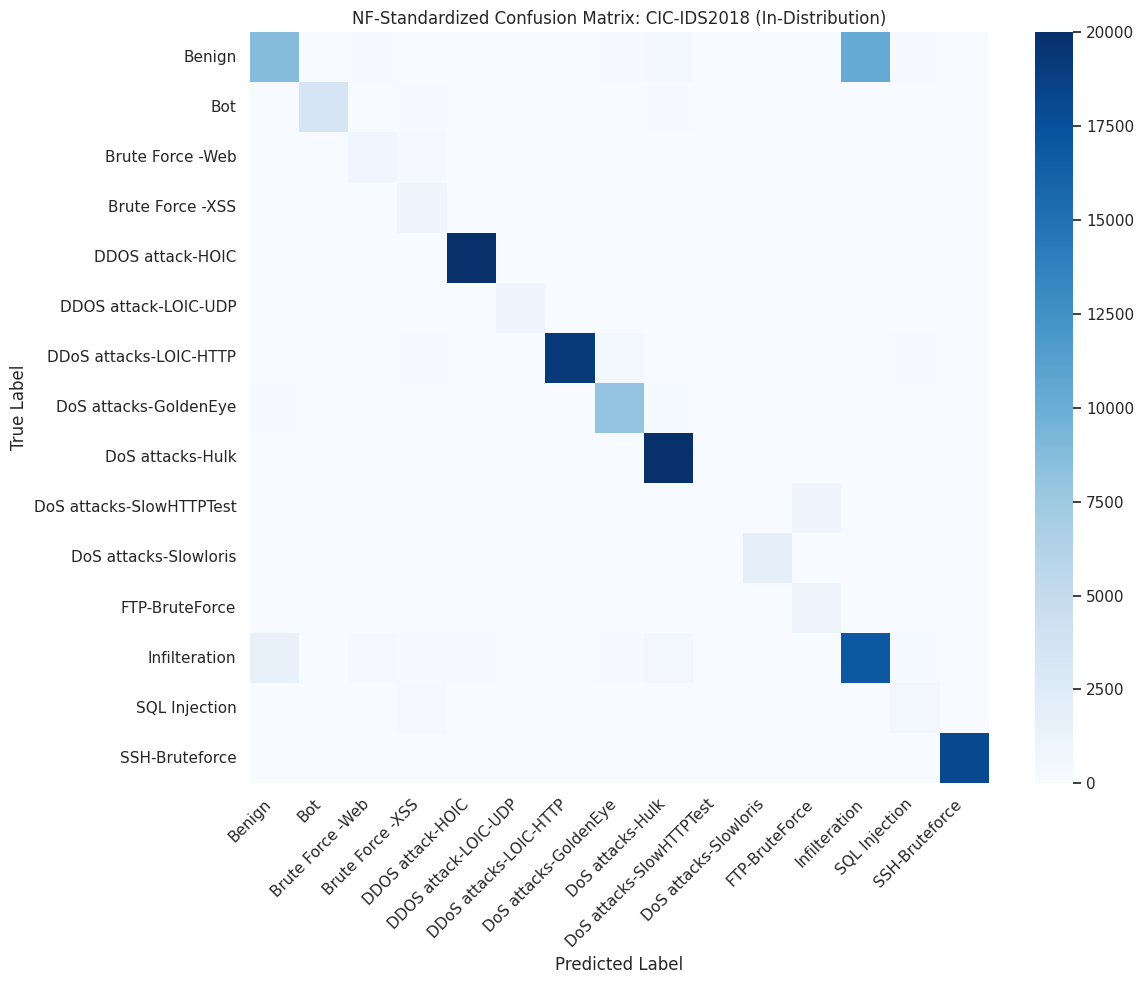

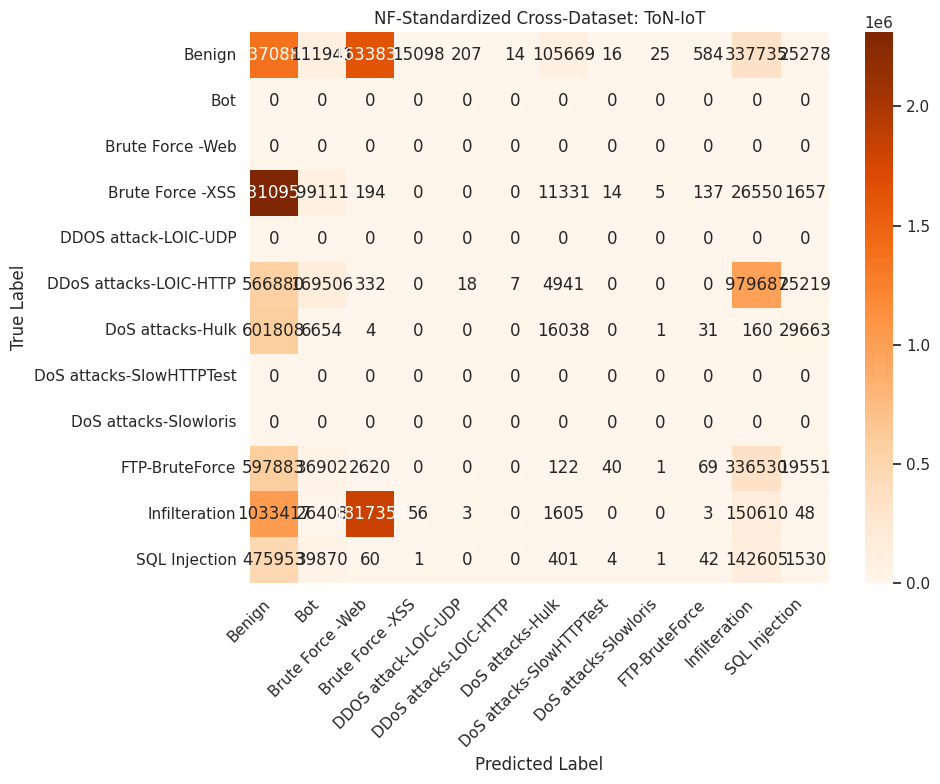

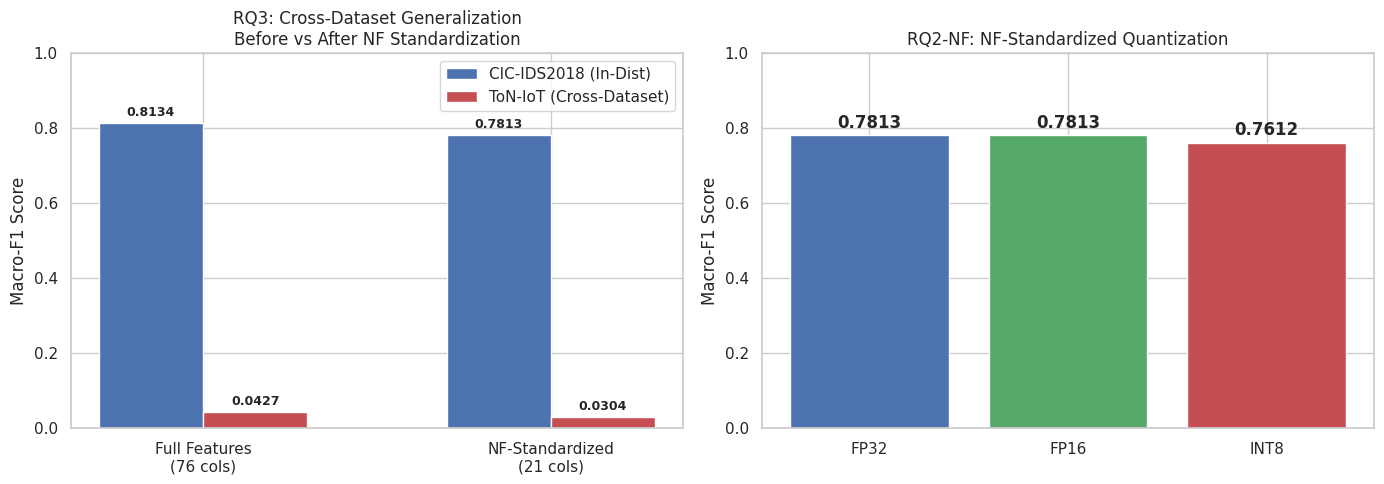


✅ All plots saved!


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# Plot 1: NF Confusion Matrix — CIC-IDS2018 (In-distribution)
# ---------------------------------------------------------
sess = ort.InferenceSession("/kaggle/working/threat_mlp_nf_fp32.onnx", providers=["CPUExecutionProvider"])
all_preds_cic = []
for i in range(0, len(X_test_bm), 512):
    batch = X_test_bm[i:i+512].astype(np.float32)
    all_preds_cic.extend(np.argmax(sess.run(None, {"input": batch})[0], axis=1))

cm_cic = confusion_matrix(y_test_bm, all_preds_cic)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_cic, annot=False, cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('NF-Standardized Confusion Matrix: CIC-IDS2018 (In-Distribution)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/nf_confusion_matrix_cic.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# Plot 2: NF Confusion Matrix — ToN-IoT (Cross-dataset)
# ---------------------------------------------------------
all_possible_labels = np.arange(len(label_encoder.classes_))
cm_ton = confusion_matrix(y_ton_known, ton_preds, labels=all_possible_labels)

unique_labels_idx = sorted(np.unique(np.concatenate([y_ton_known, ton_preds])))
cm_ton_filtered = cm_ton[np.ix_(unique_labels_idx, unique_labels_idx)]
labels_present = [label_encoder.classes_[i] for i in unique_labels_idx]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ton_filtered, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_present,
            yticklabels=labels_present)
plt.title('NF-Standardized Cross-Dataset: ToN-IoT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/nf_confusion_matrix_toniot.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# Plot 3: Before vs After — Cross-Dataset F1 Comparison
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cross-dataset F1 comparison (before vs after NF standardization)
models = ['Full Features\n(76 cols)', 'NF-Standardized\n(21 cols)']
cic_f1s = [0.8134, fp32_results['macro_f1']]
ton_f1s = [0.0427, ton_f1]

x = np.arange(len(models))
width = 0.3
bars1 = ax1.bar(x - width/2, cic_f1s, width, label='CIC-IDS2018 (In-Dist)', color='#4C72B0')
bars2 = ax1.bar(x + width/2, ton_f1s, width, label='ToN-IoT (Cross-Dataset)', color='#C44E52')
ax1.set_title('RQ3: Cross-Dataset Generalization\nBefore vs After NF Standardization')
ax1.set_ylabel('Macro-F1 Score')
ax1.set_ylim(0, 1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=9)

# Right: NF Quantization comparison
labels_q = ['FP32', 'FP16', 'INT8']
sizes = [fp32_results['size_mb'], fp16_results['size_mb'], int8_results['size_mb']]
f1_scores = [fp32_results['macro_f1'], fp16_results['macro_f1'], int8_results['macro_f1']]

ax2.bar(labels_q, f1_scores, color=['#4C72B0', '#55A868', '#C44E52'])
ax2.set_title('RQ2-NF: NF-Standardized Quantization')
ax2.set_ylabel('Macro-F1 Score')
ax2.set_ylim(0, 1.0)
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/nf_comparison_plots.png', dpi=300)
plt.show()

print("\n✅ All plots saved!")

## Cell 8: Summary — Files to Download

After running this notebook, download the following from `/kaggle/working/`:

| File | Purpose |
|---|---|
| `threat_mlp_nf.pth` | NF-standardized PyTorch model weights |
| `threat_mlp_nf_best.pth` | Best checkpoint during training |
| `label_encoder_nf.joblib` | Label encoder (same classes as before) |
| `standard_scaler_nf.joblib` | Scaler fitted on 21 NF features only |
| `threat_mlp_nf_fp32.onnx` | FP32 ONNX model |
| `threat_mlp_nf_fp16.onnx` | FP16 quantized ONNX model |
| `threat_mlp_nf_int8.onnx` | INT8 quantized ONNX model |
| `nf_quantization_comparison.json` | RQ2-NF benchmark results |
| `nf_cross_dataset_comparison.json` | RQ3-NF cross-dataset results |
| `nf_confusion_matrix_cic.png` | In-distribution confusion matrix |
| `nf_confusion_matrix_toniot.png` | Cross-dataset confusion matrix |
| `nf_comparison_plots.png` | Before/After comparison charts |

In [24]:
# Print final summary
print("="*70)
print("  NF-STANDARDIZED TRAINING — FINAL SUMMARY")
print("="*70)
print(f"\n  Features used: {len(NF_FEATURES)} (NetFlow-standardized)")
print(f"  Classes: {num_classes}")
print(f"\n  RQ1-NF (ONNX fidelity):  {'PASSED' if all_match else 'FAILED'}")
print(f"  RQ2-NF (Quantization):")
print(f"    FP32: {fp32_results['macro_f1']:.4f} F1, {fp32_results['size_mb']:.3f} MB")
print(f"    FP16: {fp16_results['macro_f1']:.4f} F1, {fp16_results['size_mb']:.3f} MB")
print(f"    INT8: {int8_results['macro_f1']:.4f} F1, {int8_results['size_mb']:.3f} MB")
print(f"  RQ3-NF (Cross-dataset):")
print(f"    Previous ToN-IoT F1: 0.0427")
print(f"    NF ToN-IoT F1:       {ton_f1:.4f}")
print(f"    Improvement:         {ton_f1 - 0.0427:+.4f}")
print(f"\n" + "="*70)

  NF-STANDARDIZED TRAINING — FINAL SUMMARY

  Features used: 21 (NetFlow-standardized)
  Classes: 15

  RQ1-NF (ONNX fidelity):  PASSED
  RQ2-NF (Quantization):
    FP32: 0.7813 F1, 0.184 MB
    FP16: 0.7813 F1, 0.093 MB
    INT8: 0.7612 F1, 0.052 MB
  RQ3-NF (Cross-dataset):
    Previous ToN-IoT F1: 0.0427
    NF ToN-IoT F1:       0.0304
    Improvement:         -0.0123

